# 04. Темп обучения на 20 точках: быстро и переобученно или медленно и точно

| | |
|---|---|
| **Уровень** | 1 из 4 — крошечные данные: всё считается вручную (`1_tiny`) |
| **Скрипт-источник** | [`04_learning_rate_by_hand.py`](../04_learning_rate_by_hand.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 2 с |

**Цель.** Почувствовать, что делает темп ν, на данных, которые целиком видно глазами.

### Чему вы научитесь

- ν = 1 почти сразу подгоняет шум
- Маленький ν идёт медленнее, но приходит к лучшей ошибке на новых данных
- Число деревьев и темп связаны

### Данные

20 точек волны y = sin-подобная функция + шум (σ = 0.4) и 2000 новых точек для проверки.

### План

1. **Этап 1.** Данные: 20 точек для обучения, 2000 новых для проверки
2. **Этап 2.** Обучение: глубина 2, до 200 деревьев, три темпа
3. **Этап 3.** Ошибка (MSE) после k деревьев: обучение / новые данные
4. **Этап 4.** Картинка

> Ноутбук собран из `examples/1_tiny/04_learning_rate_by_hand.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example

ex = Example(EXAMPLES / "1_tiny/04_learning_rate_by_hand.py", title="04. Темп обучения на 20 точках",
             goal="сравнить ν = 1, 0.3 и 0.05 по ошибке на обучении и на новых данных")

import matplotlib.pyplot as plt
import numpy as np
from gbcourse import GBRegressor, datasets

## Этап 1. Данные: 20 точек для обучения, 2000 новых для проверки

In [2]:
X, y = datasets.regression_1d(kind="wave", n=20, noise=0.4, seed=4)
X_new, y_new = datasets.regression_1d(kind="wave", n=2000, noise=0.4, seed=5)
ex.describe(X, y, names=["x"], target="y", source="gbcourse.datasets.regression_1d(kind='wave', n=20, noise=0.4)")
ex.note(f"Лучшее, что возможно на новых данных, — MSE ≈ дисперсии шума: 0.4² = {0.4 ** 2:.2f}.")

   Источник: gbcourse.datasets.regression_1d(kind='wave', n=20, noise=0.4)
   Объектов: 20   признаков: 1   память: 0.00 МБ
   Типы признаков: float64 × 1
   Пропусков нет
   Цель «y»: среднее 1.806, σ 1.322, мин -0.166, макс 4.247
   Первые строки:


,x,[y]
0,0.773915,-0.166457
1,0.818410,1.063275
2,2.216679,1.467970


> ▸ **Вывод.** Лучшее, что возможно на новых данных, — MSE ≈ дисперсии шума: 0.4² = 0.16.

## Этап 2. Обучение: глубина 2, до 200 деревьев, три темпа

In [3]:
curves = {}
for lr in (1.0, 0.3, 0.05):
    m = GBRegressor(n_estimators=200, learning_rate=lr, max_depth=2).fit(X, y, eval_set=(X_new, y_new))
    curves[lr] = (np.array(m.history_["train"]) * 2, np.array(m.history_["eval"]) * 2)   # история — ½MSE

## Этап 3. Ошибка (MSE) после k деревьев: обучение / новые данные

In [4]:
print("   деревьев │" + "│".join(f"   ν = {lr:<4}         " for lr in curves))
for k in (1, 5, 20, 50, 200):
    print(f"   {k:8d} │" + "│".join(f"  {tr[k]:6.3f} / {ev[k]:6.3f}   " for tr, ev in curves.values()))
best = {lr: (int(np.argmin(ev)), float(ev.min())) for lr, (tr, ev) in curves.items()}
for lr, (k, v) in best.items():
    print(f"   ν = {lr:<4}: лучшая MSE на новых данных {v:.3f} при {k} деревьях")
ex.note("""ν = 1 быстро доводит ошибку на обучении почти до нуля — и начинает запоминать шум 20 точек.
Маленький темп требует больше деревьев, но его лучшая ошибка на новых данных не хуже.""")
assert curves[1.0][0][200] < curves[0.05][0][200]          # на обучении ν = 1 всегда «лучше»

   деревьев │   ν = 1.0          │   ν = 0.3          │   ν = 0.05         
          1 │   0.238 /  0.417   │   0.978 /  0.698   │   1.601 /  1.152   
          5 │   0.048 /  0.434   │   0.225 /  0.256   │   1.142 /  0.812   
         20 │   0.000 /  0.372   │   0.029 /  0.293   │   0.403 /  0.327   
         50 │   0.000 /  0.372   │   0.001 /  0.357   │   0.138 /  0.239   
        200 │   0.000 /  0.372   │   0.000 /  0.372   │   0.008 /  0.318   
   ν = 1.0 : лучшая MSE на новых данных 0.344 при 2 деревьях
   ν = 0.3 : лучшая MSE на новых данных 0.250 при 7 деревьях
   ν = 0.05: лучшая MSE на новых данных 0.238 при 46 деревьях


> ▸ **Вывод.** ν = 1 быстро доводит ошибку на обучении почти до нуля — и начинает запоминать шум 20 точек. Маленький темп требует больше деревьев, но его лучшая ошибка на новых данных не хуже.

## Этап 4. Картинка

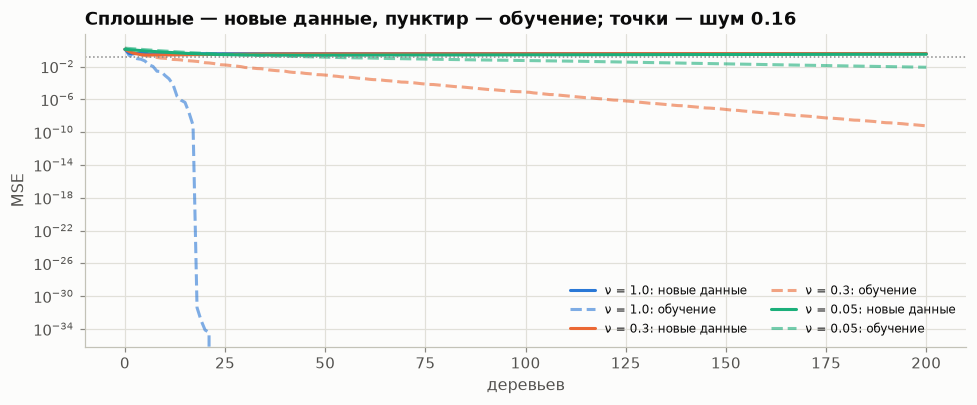

Готово за 0.6 с


In [5]:
fig, ax = plt.subplots(figsize=(9, 3.8))
for lr, (tr, ev) in curves.items():
    line, = ax.plot(ev, label=f"ν = {lr}: новые данные")
    ax.plot(tr, ls="--", color=line.get_color(), alpha=0.6, label=f"ν = {lr}: обучение")
ax.axhline(0.16, color="#888", lw=1, ls=":")
ax.set(yscale="log", xlabel="деревьев", ylabel="MSE", title="Сплошные — новые данные, пунктир — обучение; точки — шум 0.16")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
ex.finish(fig, "04_learning_rate")
ex.done()

## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Добавьте в перебор ν = 0.1 и ν = 0.01: как меняется число деревьев до минимума ошибки?
2. Увеличьте шум при генерации данных вдвое — сдвинется ли лучший темп?
3. Замените `max_depth=2` на 1 и на 4 и сравните лучшие ошибки на новых данных.

## Что дальше

- **Теория в курсе:** [4.2 «Темп обучения»](../../../lessons/lesson_4_2/README.md), [7.1 «Ранняя остановка»](../../../lessons/lesson_7_1/README.md).
- **Предыдущий пример:** [03. Бустинг для классификации вручную: 8 объектов, логиты и шаг Ньютона](03_classification_by_hand.ipynb)
- **Следующий пример:** [05. Градиентный бустинг с нуля за 30 строк — и точное совпадение с scikit-learn](../../2_small/notebooks/05_gbm_from_scratch.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)